In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



# 🛰️ Lab 5: การจัดการข้อมูล Raster ด้วย Rasterio
## วิชา GE 234 Basic Programming for Geographers

### 🎯 **วัตถุประสงค์**
1. เรียนรู้การใช้ **Rasterio** ในการอ่านและแสดงผลข้อมูล Raster
2. สามารถเข้าถึงข้อมูลเมตาของไฟล์ Raster เช่น ค่า Resolution และ CRS (Coordinate Reference System)
3. ใช้ **Rasterio** ในการตัด (Clip), บันทึก (Save), และวิเคราะห์ข้อมูล Raster
4. คำนวณค่าดัชนีพืชพรรณ **NDVI (Normalized Difference Vegetation Index)** จากข้อมูล Raster

---

## 🔹 ตัวอย่างที่ 1: อ่านข้อมูล Raster ด้วย Rasterio


In [ ]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "example.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)



## 🔹 ตัวอย่างที่ 2: แสดงผลข้อมูล Raster ด้วย Matplotlib


In [ ]:

import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()



## 🔹 ตัวอย่างที่ 3: คำนวณค่า NDVI จากภาพ Raster


In [ ]:

import numpy as np

# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:
    nir = dataset.read(4).astype(float)  # ช่อง NIR (เช่น Band 4)
    red = dataset.read(3).astype(float)  # ช่อง Red (เช่น Band 3)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



## 🔹 ตัวอย่างที่ 4: บันทึก NDVI เป็นไฟล์ GeoTIFF


In [ ]:

# บันทึกไฟล์ NDVI เป็น GeoTIFF
ndvi_output = "ndvi_output.tif"
with rasterio.open(raster_path) as src:
    profile = src.profile
    profile.update(dtype=rasterio.float32, count=1)

    with rasterio.open(ndvi_output, "w", **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print("บันทึกไฟล์ NDVI เรียบร้อย!")



## 🔹 ตัวอย่างที่ 5: ตัด (Clip) ข้อมูล Raster ตามขอบเขตที่กำหนด


In [ ]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "boundary.shp"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")



# 📝 **กิจกรรมในแลป**

1. **แบบฝึกหัด 1**: ใช้ **Rasterio** อ่านข้อมูลภาพ **Raster** และแสดงผลด้วย Matplotlib  
2. **แบบฝึกหัด 2**: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้  
3. **แบบฝึกหัด 3**: ใช้ **NumPy และ Rasterio** คำนวณค่า NDVI และแสดงผลแผนที่  
4. **แบบฝึกหัด 4**: ใช้ **Rasterio** ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile  


# **คำตอบ**

แบบฝึกหัด 1: ใช้ Rasterio อ่านข้อมูลภาพ Raster และแสดงผลด้วย Matplotlib

ข้อมูลเมตาของภาพ Raster:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 1085, 'height': 1282, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 47N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",99],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32647"]]'), 'transform': Affine(10.0, 0.0, 826780.0,
       0.0, -10.0, 1607010.0)}


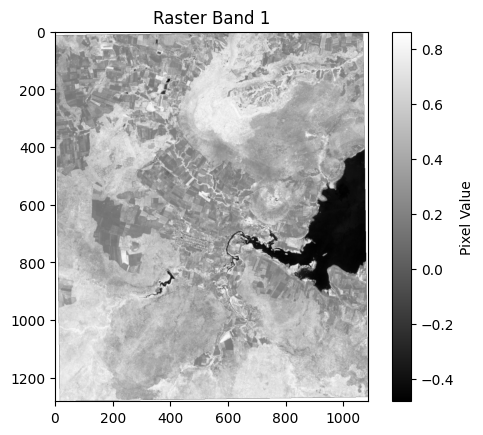

In [2]:

import rasterio

# เปิดไฟล์ Raster ตัวอย่าง
raster_path = "/content/drive/MyDrive/GEE_Exports/NDVI_Red_NIR_Export.tif"  # ใส่ path ของไฟล์ .tif
with rasterio.open(raster_path) as dataset:
    print("ข้อมูลเมตาของภาพ Raster:")
    print(dataset.meta)
import matplotlib.pyplot as plt

# อ่านข้อมูลช่องสีน้ำเงิน (Band 1)
with rasterio.open(raster_path) as dataset:
    band1 = dataset.read(1)

# แสดงภาพ Raster
plt.imshow(band1, cmap="gray")
plt.colorbar(label="Pixel Value")
plt.title("Raster Band 1")
plt.show()

แบบฝึกหัด 2: ดึงข้อมูลเมตาของไฟล์ Raster และอธิบายค่าต่าง ๆ ที่ได้

In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# เปิดไฟล์ (ยังไม่โหลดข้อมูลเข้า memory)
src = rasterio.open('/content/drive/MyDrive/GEE_Exports/NDVI_Red_NIR_Export.tif')

# ดู metadata ทั้งหมด
print("=" * 50)
print("📋 METADATA ของไฟล์ DEM")
print("=" * 50)
print(f"Driver     : {src.driver}")        # รูปแบบไฟล์
print(f"Width      : {src.width} pixels")   # จำนวนคอลัมน์
print(f"Height     : {src.height} pixels")  # จำนวนแถว
print(f"Count      : {src.count} band(s)")  # จำนวน band
print(f"CRS        : {src.crs}")            # ระบบพิกัด
print(f"Bounds     : {src.bounds}")          # ขอบเขต
print(f"Resolution : {src.res}")             # ความละเอียด (x, y)
print(f"Dtype      : {src.dtypes}")          # ชนิดข้อมูล
print(f"NoData     : {src.nodata}")          # ค่า NoData
print(f"Transform  :\n{src.transform}")      # Affine transform

📋 METADATA ของไฟล์ DEM
Driver     : GTiff
Width      : 1085 pixels
Height     : 1282 pixels
Count      : 3 band(s)
CRS        : EPSG:32647
Bounds     : BoundingBox(left=826780.0, bottom=1594190.0, right=837630.0, top=1607010.0)
Resolution : (10.0, 10.0)
Dtype      : ('float32', 'float32', 'float32')
NoData     : None
Transform  :
| 10.00, 0.00, 826780.00|
| 0.00,-10.00, 1607010.00|
| 0.00, 0.00, 1.00|


In [3]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# เปิดไฟล์ (ยังไม่โหลดข้อมูลเข้า memory)
src = rasterio.open('/content/drive/MyDrive/GEE_Exports/NDVI_Red_NIR_Export.tif')

# ดู metadata ทั้งหมด
print("=" * 50)
print("📋 METADATA ของไฟล์ DEM")
print("=" * 50)
print(f"Driver     : {src.driver}")        # รูปแบบไฟล์
print(f"Width      : {src.width} pixels")   # จำนวนคอลัมน์
print(f"Height     : {src.height} pixels")  # จำนวนแถว
print(f"Count      : {src.count} band(s)")  # จำนวน band
print(f"CRS        : {src.crs}")            # ระบบพิกัด
print(f"Bounds     : {src.bounds}")          # ขอบเขต
print(f"Resolution : {src.res}")             # ความละเอียด (x, y)
print(f"Dtype      : {src.dtypes}")          # ชนิดข้อมูล
print(f"NoData     : {src.nodata}")          # ค่า NoData
print(f"Transform  :\n{src.transform}")      # Affine transform

📋 METADATA ของไฟล์ DEM
Driver     : GTiff
Width      : 1085 pixels
Height     : 1282 pixels
Count      : 3 band(s)
CRS        : EPSG:32647
Bounds     : BoundingBox(left=826780.0, bottom=1594190.0, right=837630.0, top=1607010.0)
Resolution : (10.0, 10.0)
Dtype      : ('float32', 'float32', 'float32')
NoData     : None
Transform  :
| 10.00, 0.00, 826780.00|
| 0.00,-10.00, 1607010.00|
| 0.00, 0.00, 1.00|


แบบฝึกหัด 3: ใช้ NumPy และ Rasterio คำนวณค่า NDVI และแสดงผลแผนที่

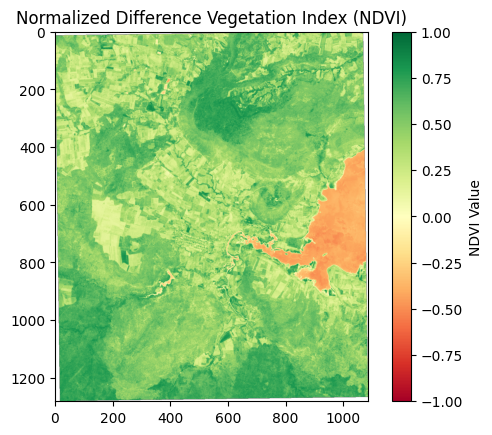

In [7]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt


# เปิดไฟล์ภาพดาวเทียม
with rasterio.open(raster_path) as dataset:

    red = dataset.read(2).astype(float)
    nir = dataset.read(3).astype(float)

# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10)  # หลีกเลี่ยงการหารด้วยศูนย์

# แสดงผล NDVI
plt.imshow(ndvi, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI Value")
plt.title("Normalized Difference Vegetation Index (NDVI)")
plt.show()



แบบฝึกหัด 4: ใช้ Rasterio ตัดข้อมูลภาพจากขอบเขตที่กำหนดในไฟล์ Shapefile

ตัดข้อมูล Raster สำเร็จ!


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3616 (\N{THAI CHARACTER PHO SAMPHAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

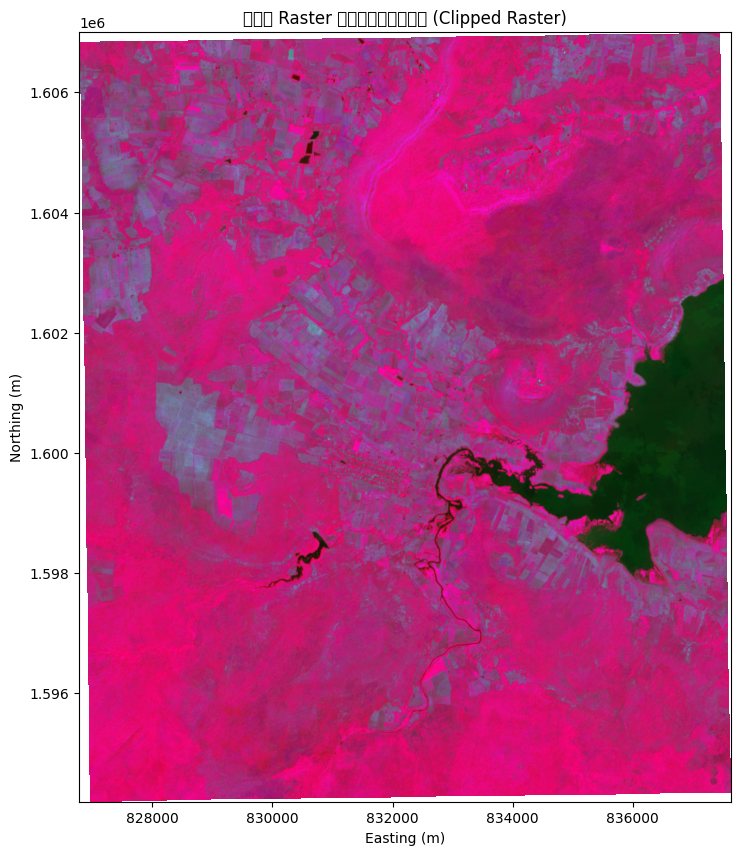

In [10]:

from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

raster_path = "/content/drive/MyDrive/GEE_Exports/NDVI_Red_NIR_Export.tif"

# โหลดไฟล์ Shapefile ของขอบเขตที่ต้องการตัด
shapefile_path = "/content/drive/MyDrive/th77_diss"  # ใส่ path ของไฟล์ขอบเขต
gdf = gpd.read_file(shapefile_path)

# แปลง Polygon เป็นรูปแบบ GeoJSON
geometry = [mapping(gdf.geometry[0])]

# ตัดภาพ Raster
with rasterio.open(raster_path) as src:
    out_image, out_transform = mask(src, geometry, crop=True)
    out_meta = src.meta.copy()

# อัปเดตเมตาดาต้าใหม่
out_meta.update({"height": out_image.shape[1], "width": out_image.shape[2], "transform": out_transform})

# บันทึกไฟล์ที่ถูกตัด
clipped_raster = "clipped_output.tif"
with rasterio.open(clipped_raster, "w", **out_meta) as dest:
    dest.write(out_image)

print("ตัดข้อมูล Raster สำเร็จ!")

# เปิดไฟล์ Raster ที่ถูกตัด
clipped_raster_path = "clipped_output.tif"
with rasterio.open(clipped_raster_path) as src:
    # แสดงภาพ Raster
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    show(src, ax=ax, cmap='viridis')
    ax.set_title("ภาพ Raster ที่ถูกตัด (Clipped Raster)")
    plt.xlabel("Easting (m)")
    plt.ylabel("Northing (m)")
    plt.show()
